In [1]:
!pip install langchain_google_genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.3 MB/s eta 0:00:00


In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

In [ ]:
# Set your Google API key here
api_key = ""  # Replace with your actual key

if not api_key or api_key == "YOUR_API_KEY_HERE":
    raise ValueError("Please set api_key to your actual GOOGLE_API_KEY")

In [4]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [5]:
subgraph_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    api_key=api_key,
    streaming=True
)

In [6]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [7]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [8]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [9]:
parent_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    api_key=api_key,
    streaming=True
)

In [10]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [11]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [12]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

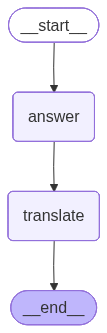

In [13]:
graph = parent_builder.compile()

graph

In [14]:
graph.invoke({'question': 'describe the king Porus in detail.'})

{'question': 'describe the king Porus in detail.',
 'answer_eng': 'King Porus was a powerful and dignified ruler of the Pauravas kingdom in ancient India, contemporary with Alexander the Great. He is primarily known for his valiant resistance against Alexander during the Macedonian invasion of India in 326 BCE.\n\nHere\'s a detailed description of King Porus:\n\n1.  **Kingdom and Region:**\n    *   Porus ruled the Pauravas kingdom, located in the Punjab region, specifically between the Hydaspes (modern Jhelum) and Acesines (modern Chenab) rivers. This strategic location made him a formidable power in the region.\n\n2.  **Physical Appearance (as described by Greek historians):**\n    *   Greek historians like Arrian and Quintus Curtius Rufus portray Porus as a man of **impressive stature and commanding presence**. He was described as exceptionally tall (over seven feet according to some accounts) and well-built, possessing a powerful physique befitting a warrior king.\n    *   During th